In [1]:
# Cell 1 - Upload kaggle.json
from google.colab import files
files.upload()  # A popup will appear — select your kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"amoolyakamath07","key":"16e8271d89b8776fd3f95a6019ef6903"}'}

In [2]:
# Cell 2 - Set up credentials
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

In [3]:
# Cell 3 - Download the dataset
!pip install kaggle -q
!kaggle datasets download -d shubham1921/real-to-ghibli-image-dataset-5k-paired-images

Dataset URL: https://www.kaggle.com/datasets/shubham1921/real-to-ghibli-image-dataset-5k-paired-images
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 543M/543M [00:03<00:00, 174MB/s]



In [4]:
# Cell 4 - Extract
import zipfile
with zipfile.ZipFile('real-to-ghibli-image-dataset-5k-paired-images.zip', 'r') as z:
    z.extractall('/content/dataset')

In [5]:
import torch
from torch import nn
import itertools
import tqdm
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader
import random
import glob
from torchvision import transforms
from PIL import Image
import os
import numpy as np
import sys

In [6]:
class Upsample_block(nn.Module):
    def __init__(self,in_ch,out_ch):
        super().__init__()
        self.upsample=nn.ConvTranspose2d(in_ch,out_ch,3,stride=2,padding=1,output_padding=1)
        self.norm=nn.InstanceNorm2d(out_ch)
        self.dropout=nn.Dropout(0.5)
        self.activation=nn.GELU()
    def forward(self,X):
        return self.activation(self.dropout(self.norm(self.upsample(X))))
class Conv_block(nn.Module):
    def __init__(self,in_ch,out_ch,kernel_size=3,stride=2,use_leaky=True,use_init_norm=True,use_pad=True):
        super().__init__()
        if use_pad:
            self.conv_layer=nn.Conv2d(in_ch,out_ch,kernel_size,stride,1,bias=True)
        else:
            self.conv_layer=nn.Conv2d(in_ch,out_ch,kernel_size,stride,0,bias=True)
        if use_leaky:
            self.activation=nn.LeakyReLU(negative_slope=0.2,inplace=True)
        else:
            self.activation=nn.GELU()
        if use_init_norm:
            self.norm=nn.InstanceNorm2d(out_ch)
        else:
            self.norm=nn.BatchNorm2d(out_ch)
    def forward(self,X):
        return self.activation(self.norm(self.conv_layer(X)))
class ResBlock(nn.Module):
    def __init__(self,ch):
        super().__init__()
        self.pad=nn.ReflectionPad2d(1)
        self.conv_block=Conv_block(ch,ch,3,1,False,True,False)
        self.conv=nn.Conv2d(ch,ch,3,1,0,bias=True)
        self.dropout=nn.Dropout(0.5)
        self.norm=nn.InstanceNorm2d(ch)
    def forward(self,X):
        X1=self.dropout(self.conv_block(self.pad(X)))
        X2=self.norm(self.conv(self.pad(X1)))
        return X2+X

In [7]:
class Generator(nn.Module):
    def __init__(self,in_ch,out_ch,ResBlock_num=6):
        super().__init__()
        model=[
            nn.ReflectionPad2d(3),
            Conv_block(in_ch,64,7,1,False,True,False),
            Conv_block(64,128,3,2,False,True,True),
            Conv_block(128,256,3,2,False,True,True)
        ]
        for _ in range(ResBlock_num):
            model.append(ResBlock(256))
        model.append(Upsample_block(256,128))
        model.append(Upsample_block(128,64))

        model.append(nn.ReflectionPad2d(3))
        model.append(nn.Conv2d(64,out_ch,7,stride=1,padding=0))
        model.append(nn.Tanh())

        self.model=nn.Sequential(*model)
    def forward(self,X):
        return self.model(X)
class Discriminator(nn.Module):
    def __init__(self,in_ch,num_layers=4):
        super().__init__()
        layers=[
            nn.Conv2d(in_ch,64,4,stride=2,padding=1),
            nn.LeakyReLU(negative_slope=0.2,inplace=False),
        ]
        layers.append(Conv_block(64,128,4,2,True,True,True))
        layers.append(Conv_block(128,256,4,2,True,True,True))
        layers.append(Conv_block(256,512,4,2,True,True,True))
        layers.append(nn.Conv2d(512,1,4,stride=1,padding=1))
        self.model=nn.Sequential(*layers)
    def forward(self,X):
        return self.model(X)

In [8]:
def init_weight(m):
    class_name=m.__class__.__name__
    if hasattr(m,"weight") and ("Conv" in class_name or "Linear" in class_name):
        nn.init.normal_(m.weight.data,0.0,0.02)
        if hasattr(m,"bias") and m.bias is not None:
            nn.init.zeros_(m.bias.data)
    elif "BatchNorm2d" in class_name:
        nn.init.normal_(m.weight,1.0,std=0.02)
        nn.init.zeros_(m.bias)

def Frozen(nets,training=True):
    for net in nets:
        for param in net.parameters():
            param.requires_grad=training

def seed_everything(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.benchmark=True

def reverse_img(img,mean=[0.5]*3,std=[0.5]*3):
    for img_channel,mean_channel,std_channel in zip(img,mean,std):
        img_channel.mul_(std_channel).add_(mean_channel)
    return img.clamp(0,1)

class sample_fake(object):
    def __init__(self,max_imgs=50):
        self.max_imgs=max_imgs
        self.imgs=[]
    def __call__(self,imgs):
        ret = []
        for img in imgs:
            if len(self.imgs) < self.max_imgs:
                self.imgs.append(img)
                ret.append(img)
            else:
                if np.random.rand() > 0.5:
                    idx = np.random.randint(0, self.max_imgs)
                    ret.append(self.imgs[idx])
                    self.imgs[idx] = img
                else:
                    ret.append(img)
        return torch.stack(ret)

class lr_sched():
    def __init__(self, decay_epochs=100, total_epochs=200):
        self.decay_epochs = decay_epochs
        self.total_epochs = total_epochs
    def step(self,epoch_num):
        if epoch_num<=self.decay_epochs:
            return 1.0
        else:
            fract=(epoch_num-self.decay_epochs)/(self.total_epochs-self.decay_epochs)
            return max(0,1.0-fract)

class Accumulator:
    def __init__(self,num):
        self.metric=[0]*num
    def __getitem__(self,idx):
        return self.metric[idx]
    def add(self,*args):
        if args:
            for i,arg in enumerate(args):
                self.metric[i]+=arg

class Recorder:
    def __init__(self,num):
        self.metric=[[] for _ in range(num)]
    def __getitem__(self,idx):
        return self.metric[idx]
    def __len__(self):
        return len(self.metric)
    def add(self,*args):
        if args:
            for i,arg in enumerate(args):
                self.metric[i].append(arg)

In [3]:
class CycleGAN:
    def __init__(self,in_ch,out_ch,configue,show_iter=None):
        self.configue=configue
        self.epochs=configue["epochs"]
        self.start_lr=configue["start_lr"]
        self.temp=configue["temp"]
        self.decay_epoch=configue["decay_epoch"] if configue["decay_epoch"] else int(self.epochs/2)
        self.idt_coef=configue["idt_coef"]
        self.device=configue["device"]
        self.show_iter=show_iter

        self.G_src2Photo=Generator(in_ch,out_ch)
        self.G_Photo2src=Generator(in_ch,out_ch)
        self.D_src=Discriminator(in_ch)
        self.D_Photo=Discriminator(in_ch)

        self.mseloss=nn.MSELoss()
        self.l1loss=nn.L1Loss()

        self.G_adam=torch.optim.Adam(itertools.chain(self.G_src2Photo.parameters(),self.G_Photo2src.parameters()),
        lr=self.start_lr, betas=(0.5, 0.999))
        self.D_adam = torch.optim.Adam(
            itertools.chain(self.D_src.parameters(), self.D_Photo.parameters()),
            lr=self.start_lr, betas=(0.5, 0.999))

        self.sample_src = sample_fake()
        self.sample_photo = sample_fake()

        G_lr = lr_sched(self.decay_epoch, self.epochs)
        D_lr = lr_sched(self.decay_epoch, self.epochs)
        self.G_sched = torch.optim.lr_scheduler.LambdaLR(self.G_adam, G_lr.step)
        self.D_sched = torch.optim.lr_scheduler.LambdaLR(self.D_adam, D_lr.step)
        self.record_metric = Recorder(2)

        self.init_model()

    def init_model(self):
        self.G_src2Photo.apply(init_weight)
        self.G_Photo2src.apply(init_weight)
        self.D_src.apply(init_weight)
        self.D_Photo.apply(init_weight)

        self.G_src2Photo = self.G_src2Photo.to(self.device)
        self.G_Photo2src = self.G_Photo2src.to(self.device)
        self.D_src = self.D_src.to(self.device)
        self.D_Photo = self.D_Photo.to(self.device)

    def visualize_result(self):
        """Helper to visualize progress using the stored iterator."""
        self.G_Photo2src.eval()
        if self.show_iter:
            try:
                try:
                    src_img, _ = next(self.show_iter)
                except StopIteration:
                    return

                img = src_img.to(self.device)
                with torch.no_grad():
                    fake = self.G_Photo2src(img)

                fake_img = reverse_img(fake.cpu()[0]).permute(1, 2, 0).numpy()
                real_img = reverse_img(img.cpu()[0]).permute(1, 2, 0).numpy()

                plt.figure(figsize=(10, 5))
                plt.subplot(1, 2, 1)
                plt.title("Original Source")
                plt.imshow(real_img)
                plt.axis("off")

                plt.subplot(1, 2, 2)
                plt.title("Generated Source")
                plt.imshow(fake_img)
                plt.axis("off")
                plt.show()
                plt.close()
            except Exception as e:
                print(f"Visualization failed: {e}")
        self.G_Photo2src.train()


In [10]:
class ImageDataset(Dataset):
    def __init__(self, src_path, photo_path, size=(256,256)):
        super().__init__()
        self.src_path=glob.glob(src_path + "/*.*")
        self.photo_path=glob.glob(photo_path + "/*.*")

        self.src_path=[x for x in self.src_path if x.lower().endswith(('.png', '.jpg', '.jpeg'))]
        self.photo_path=[x for x in self.photo_path if x.lower().endswith(('.png', '.jpg', '.jpeg'))]

        self.transforms=transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(286),
            transforms.RandomCrop(size),
            transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])])

    def __len__(self):
        return min(len(self.src_path),len(self.photo_path))

    def __getitem__(self,idx):
        photo_idx=random.randint(0, len(self.photo_path)-1)
        src_img=self.transforms(Image.open(self.src_path[idx]).convert("RGB"))
        photo_img=self.transforms(Image.open(self.photo_path[photo_idx]).convert("RGB"))
        return src_img,photo_img

configue={
    "batch_size":4,
    "seed":69,
    "epochs":50,
    "device":"cuda" if torch.cuda.is_available() else "cpu",
    "start_lr":2e-4,
    "temp":10,
    "idt_coef":0.5,
    "decay_epoch":15,
    "save":True,
    "training":True
}
def show_configue():
    print("======Configuration======")
    for key,value in configue.items():
        print(f"{key:20} {value}")
    print("\n")

In [11]:
# Find these lines and change them to:
SRC_PATH = "/content/dataset/dataset/trainA"
PHOTO_PATH = "/content/dataset/dataset/trainB_ghibli"

if not os.path.exists(SRC_PATH):
    os.makedirs(SRC_PATH,exist_ok=True)
    print(f"Created placeholder directory:{SRC_PATH}.Please add images.")
if not os.path.exists(PHOTO_PATH):
    os.makedirs(PHOTO_PATH,exist_ok=True)
    print(f"Created placeholder directory:{PHOTO_PATH}.Please add images.")

seed_everything(configue["seed"])

dataset=ImageDataset(SRC_PATH,PHOTO_PATH)
if len(dataset)==0:
    print("No images found in dataset folders. Exiting.")
else:
    dataloader=DataLoader(
        dataset,
        batch_size=configue["batch_size"],
        shuffle=True,
        pin_memory=True)

    cycle_gan = CycleGAN(
        in_ch=3,
        out_ch=3,
        configue=configue,
        show_iter=iter(dataloader))

    print("Starting training...")
    show_configue()

Starting training...
======Configuration======
batch_size           4
seed                 69
epochs               50
device               cuda
start_lr             0.0002
temp                 10
idt_coef             0.5
decay_epoch          15
save                 True
training             True




In [12]:
import torch
import os
import tqdm
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

def toggle_grad(models,requires_grad):
    """Enables or disables gradient calculation for a list of models"""
    for model in models:
        for param in model.parameters():
            param.requires_grad=requires_grad

def denormalize(img):
    """Converts a normalized tensor (-1 to 1) back to (0 to 1) for visulaisation"""
    return img*0.5+0.5

def visualize_grid(cycle_gan,dataloader,epoch,device):
    """Generates and plots a 2*N grid:[RealA,FakeB]/Real B,FakeA]"""
    cycle_gan.G_src2Photo.eval()
    cycle_gan.G_Photo2src.eval()
    try:
        src_img,photo_img=next(iter(dataloader))
    except StopIteration:
        return
    src_img=src_img.to(device)
    photo_img=photo_img.to(device)

    with torch.no_grad():
        fake_photo=cycle_gan.G_src2Photo(src_img)
        fake_src=cycle_gan.G_Photo2src(photo_img)
    real_A=denormalize(src_img.cpu())
    fake_B=denormalize(fake_photo.cpu())
    real_B=denormalize(photo_img.cpu())
    fake_A=denormalize(fake_src.cpu())

    row1=torch.cat((real_A, fake_B),dim=3)
    row2=torch.cat((real_B, fake_A),dim=3)

    grid_tensor=torch.cat((row1, row2), dim=2)

    display_grid=make_grid(grid_tensor[:4],nrow=1,padding=5,normalize=False)
    plt.figure(figsize=(10,8))
    plt.imshow(display_grid.permute(1,2,0).numpy())
    plt.axis("off")
    plt.title(f"Epoch {epoch} Visualization")
    plt.show()
    plt.close()

    cycle_gan.G_src2Photo.train()
    cycle_gan.G_Photo2src.train()

def save_checkpoint(cycle_gan, epoch,save_dir="./output"):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    torch.save(cycle_gan.G_src2Photo.state_dict(),f"{save_dir}/G_Src2Photo_ep{epoch}.pth")
    torch.save(cycle_gan.G_Photo2src.state_dict(),f"{save_dir}/G_Photo2Src_ep{epoch}.pth")
    torch.save(cycle_gan.D_src.state_dict(),f"{save_dir}/D_Src_ep{epoch}.pth")
    torch.save(cycle_gan.D_Photo.state_dict(),f"{save_dir}/D_Photo_ep{epoch}.pth")
    print(f"--> Saved checkpoint for epoch {epoch}")

def train_cycle_gan(model, data_iter):
    """
    Standalone training function for CycleGAN.

    Args:
        model: An instance of the CycleGAN class.
        data_iter: The PyTorch DataLoader.
    """
    epochs=model.configue["epochs"]
    device=model.configue["device"]

    print(f"Starting training for {epochs} epochs on {device}...")

    for epoch in range(epochs):
        add_metric=Accumulator(3)
        pbar=tqdm.tqdm(data_iter, total=len(data_iter), leave=False, desc=f"{epoch + 1}/{epochs}")

        for i,(src_img, photo_img) in enumerate(pbar):
            src_img=src_img.to(device,non_blocking=True)
            photo_img=photo_img.to(device,non_blocking=True)

            # ============================ Generator ============================
            toggle_grad([model.D_src, model.D_Photo], True)
            model.G_adam.zero_grad()

            fake_photo=model.G_src2Photo(src_img)
            fake_src=model.G_Photo2src(photo_img)
            cycle_src=model.G_Photo2src(fake_photo)
            cycle_photo=model.G_src2Photo(fake_src)
            id_src=model.G_Photo2src(src_img)
            id_photo=model.G_src2Photo(photo_img)

            id_src_loss=model.l1loss(id_src,src_img) * model.temp * model.idt_coef
            id_photo_loss=model.l1loss(id_photo,photo_img) * model.temp * model.idt_coef

            cycle_src_loss=model.l1loss(cycle_src,src_img) * model.temp
            cycle_photo_loss=model.l1loss(cycle_photo,photo_img) * model.temp

            src_disc=model.D_src(fake_src)
            photo_disc=model.D_Photo(fake_photo)
            real=torch.ones(src_disc.size()).to(device)
            src_adv_loss=model.mseloss(src_disc, real)
            photo_adv_loss=model.mseloss(photo_disc, real)

            G_total_loss=id_src_loss+id_photo_loss+cycle_src_loss+cycle_photo_loss+src_adv_loss+photo_adv_loss
            G_total_loss.backward()
            model.G_adam.step()

            # ============================ Discriminator ============================
            toggle_grad([model.D_src, model.D_Photo],False)
            model.D_adam.zero_grad()

            fake_src_det=model.sample_src(fake_src.detach().clone()).to(device)
            fake_photo_det=model.sample_photo(fake_photo.detach().clone()).to(device)

            src_real_disc=model.D_src(src_img)
            src_fake_disc=model.D_src(fake_src_det)
            photo_real_disc=model.D_Photo(photo_img)
            photo_fake_disc=model.D_Photo(fake_photo_det)

            real_desc=torch.full_like(src_real_disc, 0.9, device=device)
            fake_desc=torch.zeros_like(src_fake_disc, device=device)

            src_real_loss=model.mseloss(src_real_disc,real_desc)
            src_fake_loss=model.mseloss(src_fake_disc,fake_desc)
            photo_real_loss=model.mseloss(photo_real_disc,real_desc)
            photo_fake_loss=model.mseloss(photo_fake_disc,fake_desc)

            D_total_loss=(src_real_loss+src_fake_loss+photo_real_loss+photo_fake_loss)*0.5
            D_total_loss.backward()
            model.D_adam.step()

            add_metric.add(G_total_loss.item(),D_total_loss.item(),len(src_img))
            pbar.set_postfix(G_loss=f"{G_total_loss.item():.4f}",D_loss=f"{D_total_loss.item():.4f}")

        model.record_metric.add(add_metric[0]/add_metric[-1],add_metric[1]/add_metric[-1])
        model.G_sched.step()
        model.D_sched.step()
        print(f"<{epoch + 1}/{epochs}>  G_loss--->{model.record_metric[0][-1]}   D_loss--->{model.record_metric[1][-1]}")

        visualize_grid(model,data_iter,epoch,device)
        if (epoch + 1) % save_freq == 0 or (epoch + 1) == epochs:
            save_checkpoint(model, epoch + 1, save_dir=output_dir)



In [13]:
torch.set_float32_matmul_precision('high')

======Configuration======
batch_size           4
seed                 69
epochs               50
device               cuda
start_lr             0.0002
temp                 10
idt_coef             0.5
decay_epoch          15
save                 True
training             True



  WGAN-GP CycleGAN | 50 epochs | cuda | n_critic=2
     Epoch      G Loss      D Loss
  -----------------------------------


    1/50        2.0548      2.4070


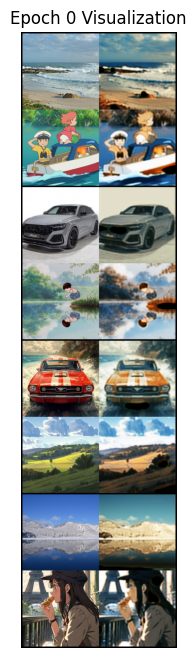

    2/50        1.5758      0.0575


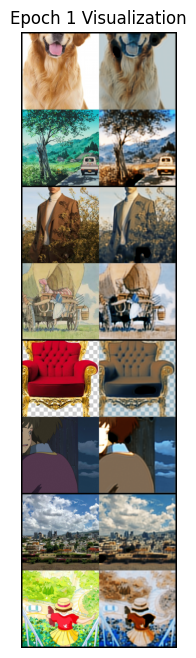

    3/50        1.4510      0.0648


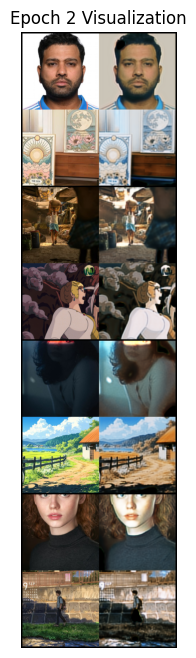

    4/50        1.3629      0.0730


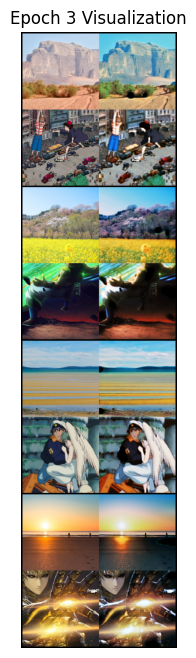

    5/50        1.2868      0.0446


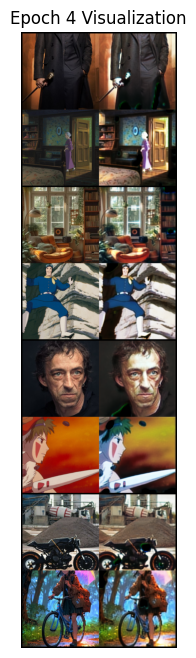

--> Saved checkpoint for epoch 5


    6/50        1.2658      0.0454


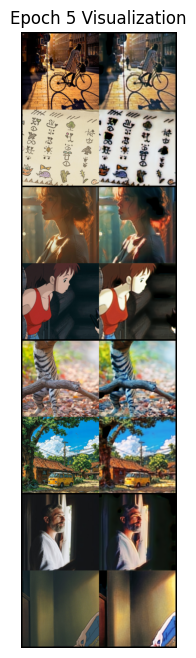

    7/50        1.2296      0.0447


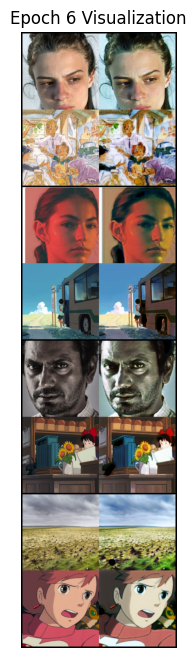

    8/50        1.2016      0.0717


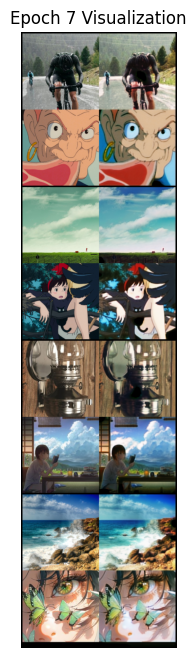

    9/50        1.1732      0.0481


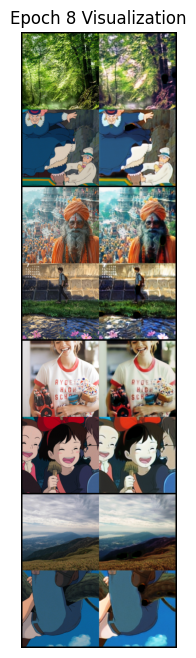

   10/50        1.1600      0.0288


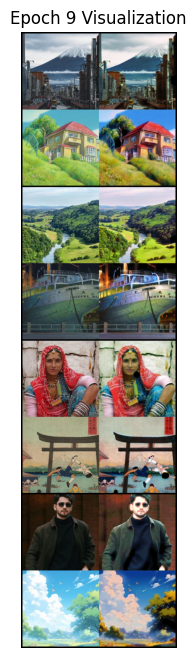

--> Saved checkpoint for epoch 10


   11/50        1.1478      0.0064


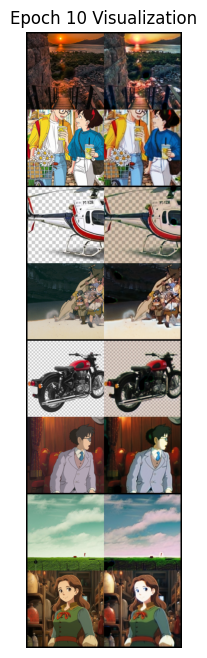

   12/50        1.1099      0.0076


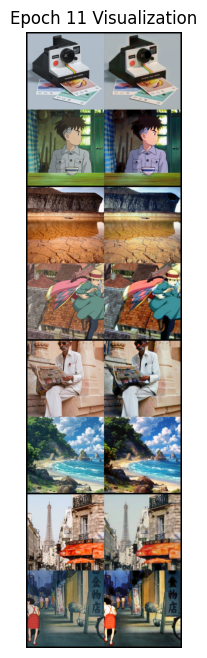

   13/50        1.0689     -0.0119


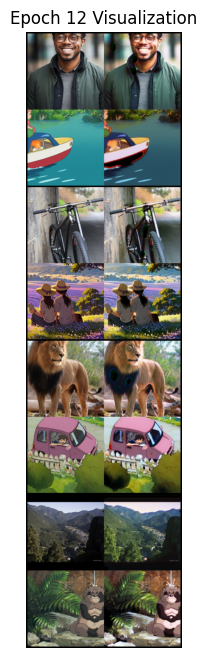

  Ep 14/50:  51%|█████     | 319/625 [11:40<11:12,  2.20s/it, D=-0.227, G=5.271]

In [ ]:
import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger("torch._inductor").setLevel(logging.ERROR)
logging.getLogger("torch._dynamo").setLevel(logging.ERROR)

class Generator(nn.Module):
    def __init__(self, in_ch, out_ch, ResBlock_num=6):
        super().__init__()
        model = [
            nn.ReflectionPad2d(3),
            Conv_block(in_ch,64,7,1, False,True,False),
            Conv_block(64,128,3,2, False,True,True),
            Conv_block(128,256,3,2, False,True,True),
        ]
        for _ in range(ResBlock_num):
            model.append(ResBlock(256))
        model.append(Upsample_block(256, 128))
        model.append(Upsample_block(128, 64))
        model.append(nn.ReflectionPad2d(3))
        model.append(nn.Conv2d(64,out_ch,7,stride=1,padding=0))
        model.append(nn.Tanh())
        self.model=nn.Sequential(*model)
    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        def sn(layer):
            return nn.utils.spectral_norm(layer)
        self.model=nn.Sequential(
            sn(nn.Conv2d(in_ch,64,4,stride=2,padding=1)),
            nn.LeakyReLU(0.2,inplace=False),
            sn(nn.Conv2d(64,128,4,stride=2,padding=1)),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2,inplace=False),
            sn(nn.Conv2d(128,256,4,stride=2,padding=1)),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2,inplace=False),
            sn(nn.Conv2d(256,512,4,stride=2,padding=1)),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2,inplace=False),
            sn(nn.Conv2d(512,1,4,stride=1,padding=1)),
        )
    def forward(self, x):
             return self.model(x)

def gradient_penalty(D,real,fake,device,lambda_gp=10.0):
    B =real.size(0)
    alpha=torch.rand(B,1,1,1,device=device)
    interp=(alpha * real.detach()+(1-alpha)*fake.detach()).requires_grad_(True)
    d_out=D(interp)
    grad=torch.autograd.grad(
        outputs=d_out,inputs=interp,
        grad_outputs=torch.ones_like(d_out),
        create_graph=True,retain_graph=True,only_inputs=True,)[0]
    gp =((grad.view(B,-1).norm(2,dim=1)-1)**2).mean()
    return lambda_gp*gp

class CycleGAN(CycleGAN):
    def init_model(self):
        for net in [self.G_src2Photo,self.G_Photo2src,self.D_src,self.D_Photo]:
            net.apply(init_weight)
            net.to(self.device)

def train_cycle_gan(model, data_iter, n_critic=5, lambda_gp=10.0,
                    save_every=5, vis_every=1):

    epochs=model.configue["epochs"]
    device=model.configue["device"]
    save=model.configue.get("save",True)

    print(f"\n{'='*55}")
    print(f"  WGAN-GP CycleGAN | {epochs} epochs | {device} | n_critic={n_critic}")
    print(f"{'='*55}")
    print(f"  {'Epoch':>8}  {'G Loss':>10}  {'D Loss':>10}")
    print(f"  {'-'*35}")

    for epoch in range(epochs):
        acc = Accumulator(3)
        pbar= tqdm.tqdm(data_iter,total=len(data_iter),leave=False,
                         desc=f"  Ep {epoch+1}/{epochs}")

        for src_img,photo_img in pbar:
            src_img=src_img.to(device, non_blocking=True)
            photo_img = photo_img.to(device, non_blocking=True)
            toggle_grad([model.D_src, model.D_Photo],True)
            toggle_grad([model.G_src2Photo, model.G_Photo2src], False)

            for _ in range(n_critic):
                model.D_adam.zero_grad(set_to_none=True)
                with torch.no_grad():
                    fake_photo= model.G_src2Photo(src_img)
                    fake_src=model.G_Photo2src(photo_img)

                fake_src_buf=model.sample_src(fake_src.detach()).to(device)
                fake_photo_buf= model.sample_photo(fake_photo.detach()).to(device)
                d_src= (model.D_src(fake_src_buf).mean()
                           - model.D_src(src_img).mean()
                           + gradient_penalty(model.D_src,src_img,fake_src_buf,device,lambda_gp))
                d_photo= (model.D_Photo(fake_photo_buf).mean()
                           - model.D_Photo(photo_img).mean()
                           + gradient_penalty(model.D_Photo, photo_img, fake_photo_buf, device, lambda_gp))
                D_loss= (d_src+d_photo)*0.5
                D_loss.backward()
                model.D_adam.step()

            toggle_grad([model.D_src, model.D_Photo],False)
            toggle_grad([model.G_src2Photo, model.G_Photo2src], True)
            model.G_adam.zero_grad(set_to_none=True)

            fake_photo = model.G_src2Photo(src_img)
            fake_src= model.G_Photo2src(photo_img)
            cycle_src= model.G_Photo2src(fake_photo)
            cycle_photo= model.G_src2Photo(fake_src)
            id_src= model.G_Photo2src(src_img)
            id_photo= model.G_src2Photo(photo_img)

            id_loss =(model.l1loss(id_src,src_img)+ model.l1loss(id_photo, photo_img)) * model.temp * model.idt_coef
            cycle_loss =(model.l1loss(cycle_src,   src_img)+ model.l1loss(cycle_photo, photo_img)) * model.temp
            adv_loss= (-model.D_src(fake_src).mean()- model.D_Photo(fake_photo).mean())

            G_loss=id_loss+cycle_loss+adv_loss
            G_loss.backward()
            model.G_adam.step()

            acc.add(G_loss.item(),D_loss.item(),src_img.size(0))
            pbar.set_postfix(G=f"{G_loss.item():.3f}", D=f"{D_loss.item():.3f}")

        g_avg = acc[0]/acc[2]
        d_avg = acc[1]/acc[2]
        model.record_metric.add(g_avg, d_avg)
        model.G_sched.step()
        model.D_sched.step()
        print(f"  {epoch+1:>3}/{epochs:<3}   {g_avg:>10.4f}  {d_avg:>10.4f}")

        if (epoch+1)%vis_every == 0:
            visualize_grid(model,data_iter,epoch,device)
        if save and (epoch+1)%save_every == 0:
            save_checkpoint(model,epoch+1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(model.record_metric[0], color="#4C72B0", linewidth=2)
    axes[0].set_title("Generator Loss"); axes[0].set_xlabel("Epoch")
    axes[0].grid(alpha=0.3)
    axes[1].plot(model.record_metric[1], color="#DD8452", linewidth=2)
    axes[1].set_title("Discriminator Loss (WGAN)"); axes[1].set_xlabel("Epoch")
    axes[1].grid(alpha=0.3)
    plt.suptitle("CycleGAN (WGAN-GP) Training", fontweight="bold")
    plt.tight_layout(); plt.show(); plt.close()
    print("\n  Training complete.")

seed_everything(configue["seed"])

dataset=ImageDataset(SRC_PATH,PHOTO_PATH)
dataloader=DataLoader(dataset,batch_size=configue["batch_size"],shuffle=True, pin_memory=True, num_workers=2)
cycle_gan=CycleGAN(in_ch=3, out_ch=3, configue=configue,show_iter=iter(dataloader))
show_configue()
train_cycle_gan(cycle_gan,dataloader,n_critic=2,lambda_gp=10.0,save_every=5,vis_every=1)